In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,CIR_PWR,MAX_NOISE,RXPACC
0,0,3.90,745,18712,10250,11576,11855,967,611
1,0,0.66,749,11239,6313,4712,18968,1133,447
2,1,7.86,746,4355,5240,3478,14699,894,723
3,1,3.48,750,8502,8416,5890,8748,1127,1024
4,0,1.19,746,17845,18095,12058,11380,1744,276


In [2]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

SVM Test Accuracy: 0.8551587301587301

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      6278
           1       0.91      0.79      0.84      6322

    accuracy                           0.86     12600
   macro avg       0.86      0.86      0.85     12600
weighted avg       0.86      0.86      0.85     12600

Confusion Matrix:
[[5802  476]
 [1349 4973]]


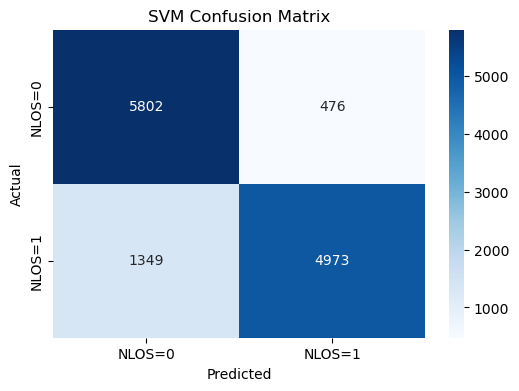

In [4]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the SVM classifier (using a linear kernel as an example)
svm_model = SVC(kernel='linear', random_state=111)

# 2. Train the SVM on the training data
svm_model.fit(X_train, y_train)

# 3. Predict on the test set
y_pred_svm = svm_model.predict(X_test)

# 4. Evaluate the performance
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Test Accuracy:", accuracy_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# 5. Compute and display the confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:")
print(cm_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()
